In [1]:
!pip install -U tensorflow scikit-learn==1.4.2 scikeras matplotlib seaborn river


In [2]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/Combined.csv'

# Read the CSV
data = pd.read_csv(file_path)

# Display first few rows
data.head()

Mounted at /content/drive


/tmp/ipykernel_2188/4143662039.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.feature_selection import f_classif, SelectKBest
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop

# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Encode categorical columns
ohe_cols = ['Proto', 'State', 'Cause', 'sDSb', 'dDSb']
ohe_cols = [c for c in ohe_cols if c in data.columns]

if ohe_cols:
    data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

In [4]:
if data['Label'].dtype == object:
    data['binary_label'] = data['Label'].apply(
        lambda x: 0 if str(x).strip().lower() in ('Benign','0') else 1
    ).astype(int)
else:
    # numeric: treat 0 as benign, non-zero as attack
    data['binary_label'] = (data['Label'] != 0).astype(int)

print("Binary label distribution (full dataset):")
print(data['binary_label'].value_counts())

#  Filter attack-only data
attack_data = data.loc[data['binary_label'] == 1].copy()


if 'Attack Type' in attack_data.columns:
    print("\nUnique values in 'Attack Type' (preview):")
    print(pd.Series(attack_data['Attack Type'].unique())[:50])

#  Categorize attack type
def categorize_attack_type(atk):
    if atk == 'Benign':
        return 'Benign'
    elif atk in ['ICMPFlood','UDPFlood','SYNFlood','HTTPFlood']:
        return 'DoS'
    elif atk in [ 'SYNScan' , 'TCPConnectScan' , 'UDPScan' ]:
        return 'Scan'
    else:
        return 'SlowrateDoS'



attack_data['Attack_Category'] = attack_data['Attack Type'].apply(categorize_attack_type)

# Encode categories
label_encoder = LabelEncoder()
attack_data['Attack_Category'] = label_encoder.fit_transform(attack_data['Attack_Category'])

Binary label distribution (full dataset):
binary_label
1    1215890
Name: count, dtype: int64

Unique values in 'Attack Type' (preview):
0            Benign
1           SYNScan
2    TCPConnectScan
3           UDPScan
4         ICMPFlood
5          UDPFlood
6          SYNFlood
7         HTTPFlood
8       SlowrateDoS
dtype: object


In [5]:
print(pd.Series(attack_data['Attack_Category']).value_counts())


Attack_Category
1    609028
0    477737
3     73124
2     56001
Name: count, dtype: int64


In [6]:
X_cat=attack_data.drop(['Label','binary_label','Attack_Category','Attack Type', 'Attack Tool','Unnamed: 0'],axis=1,errors='ignore')
y_cat=attack_data['Attack_Category']

# Compute ANOVA F-score
f_scores, p_values = f_classif(X_cat, y_cat)

# Create a readable table
anova_results = pd.DataFrame({
    "Feature": X_cat.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

anova_results = anova_results.sort_values(by="F-Score", ascending=False)

print("ANOVA selected features:", anova_results)

ANOVA selected features:        Feature        F-Score   P-Value
11       sHops  253970.561337  0.000000
48   Proto_tcp  220277.126943  0.000000
0          Seq  184834.205037  0.000000
49   Proto_udp  154060.631772  0.000000
19      Offset  140872.567088  0.000000
..         ...            ...       ...
39  DstTCPBase       1.010001  0.387023
64     sDSb_54       0.515034  0.671901
76    dDSb_cs4       0.515034  0.671901
36        sVid            NaN       NaN
37        dVid            NaN       NaN

[78 rows x 3 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [7]:
#Apply ANOVA to Select TOP 10 Features
selector = SelectKBest(score_func=f_classif, k=10)
X_anova = selector.fit_transform(X_cat, y_cat)

#Get the Names of Selected Features
selected_indices = selector.get_support(indices=True)
top_10_features = X_cat.columns[selected_indices]

print(" Top 10 Features from ANOVA:")
print(top_10_features)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


 Top 10 Features from ANOVA:
Index(['Seq', 'Min', 'Max', 'sTtl', 'sHops', 'Offset', 'AckDat', 'Proto_tcp',
       'Proto_udp', 'State_CON'],
      dtype='object')


In [8]:
X_cat = X_cat[top_10_features]

anova_scores = pd.DataFrame({
    "Feature": X_cat.columns,
    "F_Score": selector.scores_[selected_indices],
    "p_value": selector.pvalues_[selected_indices]
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)
print(anova_scores.head(10))

     Feature        F_Score  p_value
4      sHops  253970.561337      0.0
7  Proto_tcp  220277.126943      0.0
0        Seq  184834.205037      0.0
8  Proto_udp  154060.631772      0.0
5     Offset  140872.567088      0.0
3       sTtl   91477.258332      0.0
9  State_CON   75815.485941      0.0
6     AckDat   64128.645183      0.0
1        Min   53377.688956      0.0
2        Max   53377.688956      0.0


In [9]:
#  Train/Val/Test Split
X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
    X_cat, y_cat, test_size=0.1, stratify=y_cat, random_state=42
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_temp_c, y_temp_c, test_size=1/9, stratify=y_temp_c, random_state=42
)


In [10]:
#  Balance classes
df_train = pd.concat([X_train_c, y_train_c], axis=1)
min_samples = df_train['Attack_Category'].value_counts().min()

balanced_classes = []
for label in df_train['Attack_Category'].unique():
    class_subset = df_train[df_train['Attack_Category'] == label]
    class_up = resample(class_subset, replace=True, n_samples=min_samples, random_state=42)
    balanced_classes.append(class_up)

df_train_bal = pd.concat(balanced_classes, ignore_index=True)

X_train_bal_c = df_train_bal.drop('Attack_Category', axis=1)
y_train_bal_c = df_train_bal['Attack_Category']

#  Normalize
scaler = StandardScaler()
X_train_bal_c = scaler.fit_transform(X_train_bal_c)
X_val_c = scaler.transform(X_val_c)
X_test_c = scaler.transform(X_test_c)

In [11]:
#Build VAE
from tensorflow.keras import layers, Model

input_dim = X_train_bal_c.shape[1]
latent_dim = 10

encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(input_dim)(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")

In [12]:
#VAE loss
class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [13]:
#compile model
vae = VAE(encoder, decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam(), loss="mse")

In [14]:
#Train VAE
vae.fit(
    X_train_bal_c,
    epochs=30,
    batch_size=128,
    validation_data=(X_val_c, X_val_c), # Changed validation_data from (X_val, None) to (X_val, X_val)
    verbose=1
)

Epoch 1/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - kl_loss: 2.4801 - loss: 5.2463 - reconstruction_loss: 2.7663 - val_loss: 0.2378
Epoch 2/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - kl_loss: 2.3543 - loss: 3.5942 - reconstruction_loss: 1.2399 - val_loss: 0.1835
Epoch 3/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - kl_loss: 3.8048 - loss: 4.9871 - reconstruction_loss: 1.1823 - val_loss: 0.1744
Epoch 4/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - kl_loss: 2.8310 - loss: 5.2196 - reconstruction_loss: 2.3885 - val_loss: 0.1725
Epoch 5/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - kl_loss: 2.7263 - loss: 3.4421 - reconstruction_loss: 0.7158 - val_loss: 0.1666
Epoch 6/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - kl_loss: 2.6374 - loss: 3.7888 - reconstruction_loss: 1.1514 - val_loss: 0.1695
Epoch 7/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - kl_loss: 2.7379 - loss: 3.5333 - reconstruction_loss: 0.7954 - val_loss: 0.1623
Epoch 8/30
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms

In [15]:
#Extract latent features
z_mean, _, _ = encoder.predict(X_train_bal_c)
X_train_latent = z_mean

z_mean, _, _ = encoder.predict(X_val_c)
X_val_latent = z_mean

z_mean, _, _ = encoder.predict(X_test_c)
X_test_latent = z_mean

5601/5601 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3800/3800 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


In [16]:
#Train XGBoost Classifier

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train_latent, y_train_bal_c)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
from collections import deque
from river.drift import ADWIN
# Sliding window to store recent prediction probabilities
# This window helps compute adaptive thresholds
prob_window = deque(maxlen=1500)

# Minimum samples before adaptive threshold starts
MIN_SAMPLES_BEFORE_ADAPT = 30


# Initialize ADWIN drift detector
# ADWIN monitors prediction error and detects statistical changes
drift_detector = ADWIN()

# List to store drift detection points
drift_points = []

# Store predicted probabilities for analysis
y_probs_all = []

In [18]:
# Multi-class predictions (no thresholding)
y_pred = xgb_model.predict(X_test_latent)

# Convert to numpy
y_test_np = y_test_c.values

# Store drift-related info
drift_points = []
errors = []

from river.drift import ADWIN
drift_detector = ADWIN()

# Simulate streaming prediction for drift detection
for i in range(len(y_pred)):

    # Current prediction vs actual
    pred = y_pred[i]
    true = y_test_np[i]

    # Compute error (0 = correct, 1 = wrong)
    error = int(pred != true)
    errors.append(error)

    # Update drift detector
    drift_detector.update(error)

    if drift_detector.drift_detected:
        print(f"Drift detected at sample {i}")
        drift_points.append(i)

        # Use recent TEST samples (not training data)
        start = max(0, i - 500)

        X_recent = X_test_latent[start:i]
        y_recent = y_test_np[start:i]

        # Retrain only if enough samples
        if len(X_recent) > 50:
            xgb_model.fit(X_recent, y_recent)


 Test Set Results:
Adaptive Accuracy: 0.9866846507496566

[LEVEL 2] Attack Category Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.99      1.00     47774
         DoS       1.00      0.98      0.99     60903
        Scan       0.99      1.00      1.00      5600
 SlowrateDoS       0.84      0.99      0.91      7312

    accuracy                           0.99    121589
   macro avg       0.96      0.99      0.97    121589
weighted avg       0.99      0.99      0.99    121589



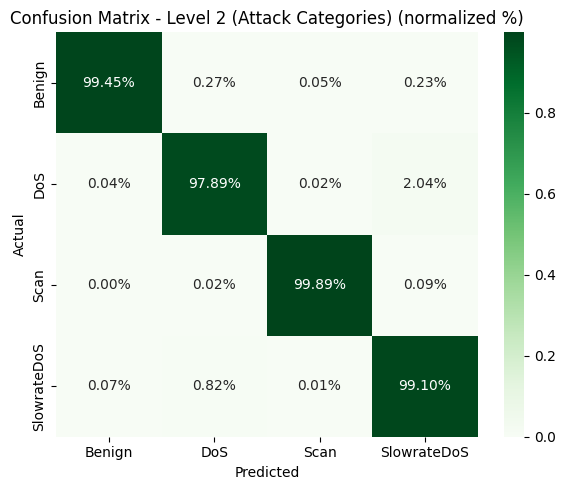

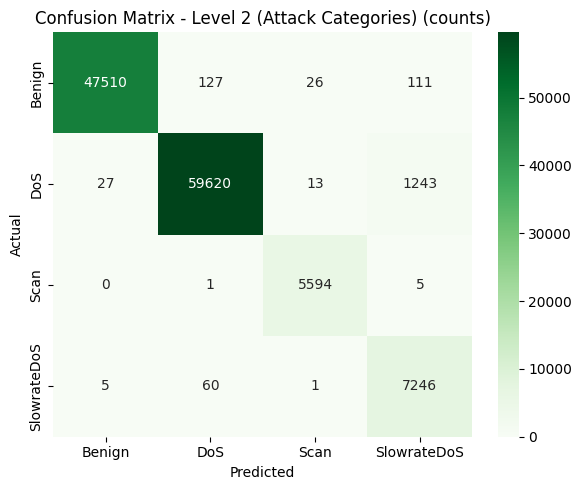

In [19]:
print("\n Test Set Results:")
print("Adaptive Accuracy:", accuracy_score(y_test_np, y_pred))

print("\n[LEVEL 2] Attack Category Classification Report:")
print(classification_report(y_test_np, y_pred, target_names=label_encoder.classes_))

# Compute confusion matrix (counts)
cm = confusion_matrix(y_test_np, y_pred)

# Normalize confusion matrix (row-wise)
cm1= cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt=".2%", cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Level 2 (Attack Categories) (normalized %)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot Raw confusion matrix
cm2 = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Level 2 (Attack Categories) (counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

